In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# Simulation parameters
fs_continuous = 10_000  # Hz
duration = 1.0          # seconds

t = np.arange(0, duration, 1 / fs_continuous)

# Signal components
f1 = 50    # Hz
f2 = 400   # Hz
f3 = 750   # Hz

x = (
    np.sin(2 * np.pi * f1 * t)
    + 0.5 * np.sin(2 * np.pi * f2 * t)
    + 0.3 * np.sin(2 * np.pi * f3 * t)
)

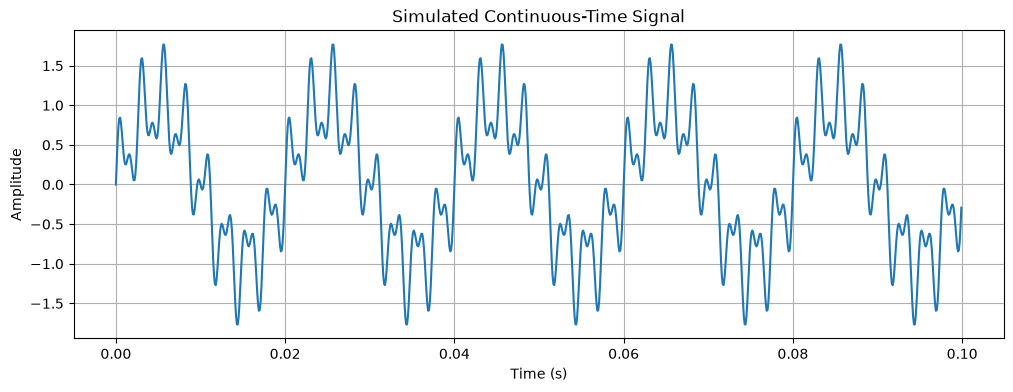

In [3]:
plt.figure(figsize=(12, 4))

plt.plot(t[:1000], x[:1000])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simulated Continuous-Time Signal")
plt.grid(True)
plt.show()

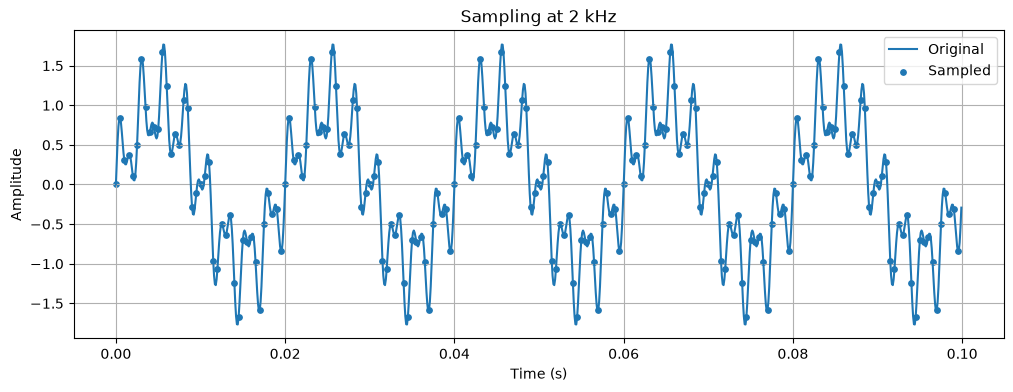

In [9]:
fs = 2_000 #hz ADC sampling

sample_indices = np.arange(0, len(t), fs_continuous // fs)

t_sampled = t[sample_indices]
x_sampled = x[sample_indices]

plt.figure(figsize=(12, 4))

plt.plot(t[:1000], x[:1000], label="Original")
plt.scatter(
    t_sampled[:200],
    x_sampled[:200],
    s=15,
    label="Sampled"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sampling at 2 kHz")
plt.legend()
plt.grid(True)
plt.show()

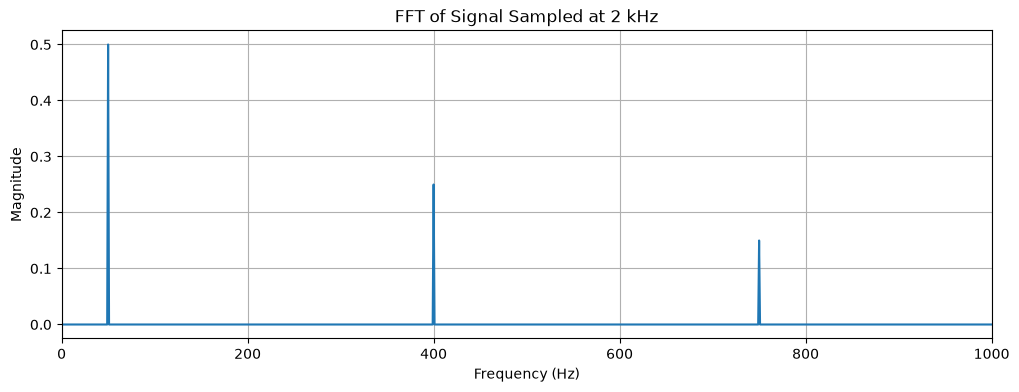

In [12]:
# FFT of sampled signal
N = len(x_sampled)

X = np.fft.rfft(x_sampled)
freqs = np.fft.rfftfreq(N, 1/fs)

magnitude = np.abs(X) / N

plt.figure(figsize=(12,4))

plt.plot(freqs, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of Signal Sampled at 2 kHz")
plt.xlim(0, .5*fs)
plt.grid(True)
plt.show()

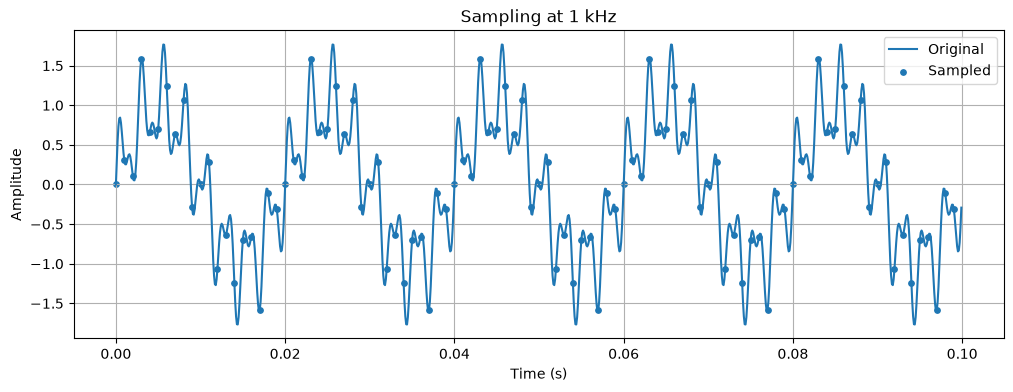

In [13]:
fs = 1_000 #hz ADC sampling

sample_indices = np.arange(0, len(t), fs_continuous // fs)

t_sampled = t[sample_indices]
x_sampled = x[sample_indices]

plt.figure(figsize=(12, 4))

plt.plot(t[:1000], x[:1000], label="Original")
plt.scatter(
    t_sampled[:100],
    x_sampled[:100],
    s=15,
    label="Sampled"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sampling at 1 kHz")
plt.legend()
plt.grid(True)
plt.show()

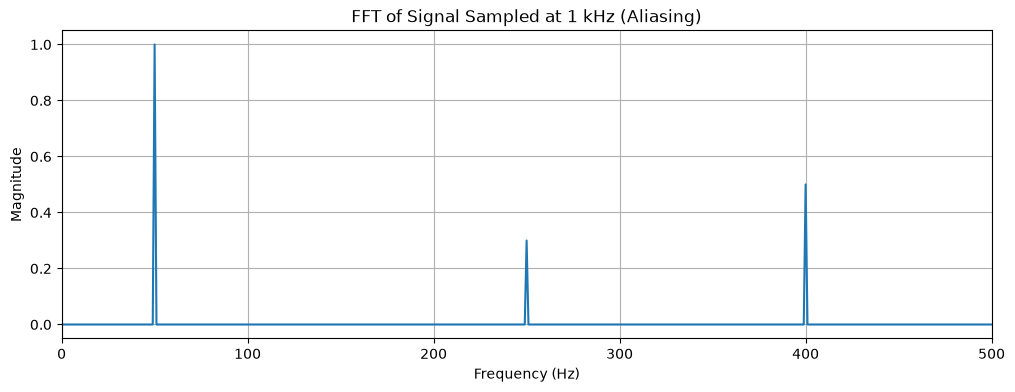

In [26]:
# FFT of sampled signal
N = len(x_sampled)

X = np.fft.rfft(x_sampled)
freqs = np.fft.rfftfreq(N, 1/fs)

magnitude = np.abs(X) / N
magnitude[1:-1] *= 2

plt.figure(figsize=(12,4))

plt.plot(freqs, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of Signal Sampled at 1 kHz (Aliasing)")
plt.xlim(0, .5*fs)
plt.grid(True)
plt.show()


In [23]:
# Anti-aliasing filter
cutoff = 100  # Hz
order = 4

b, a = signal.butter(
    order,
    cutoff,
    btype="lowpass",
    fs=fs_continuous
)

In [24]:
x_filtered = signal.lfilter(b, a, x)
x_filtered_sampled = x_filtered[::fs_continuous // fs]
t_filtered_sampled = t[::fs_continuous // fs]

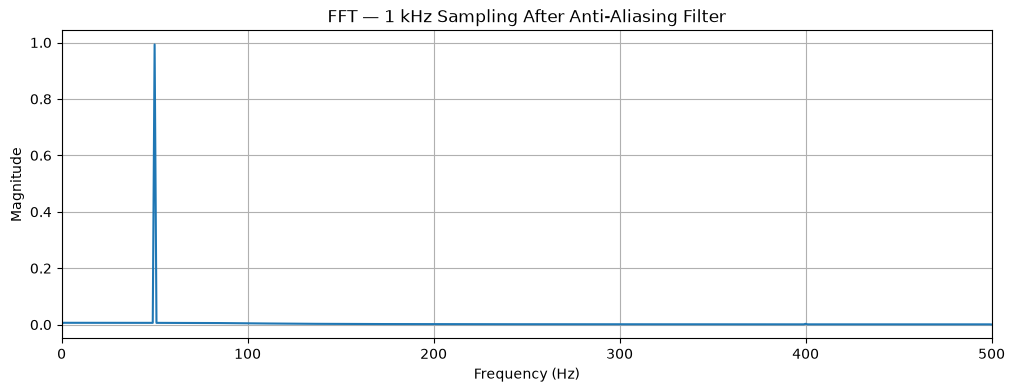

In [28]:
N = len(x_filtered_sampled)

X_filtered = np.fft.rfft(x_filtered_sampled)
freqs_filtered = np.fft.rfftfreq(N, 1 / fs)

magnitude_filtered = np.abs(X_filtered) / N
magnitude_filtered[1:-1] *= 2

plt.figure(figsize=(12, 4))
plt.plot(freqs_filtered, magnitude_filtered)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT — 1 kHz Sampling After Anti-Aliasing Filter")
plt.xlim(0, 500)
plt.grid(True)
plt.show()